# Trailing Stop Loss Impact Analysis
The goal of this notebook is to identify the ideal trailing SL level based on historically similar events

In [1]:
from util.exit_strategy import simulate_trailing_stop, simulate_volume_exit
from util.plot import plot_lines_with_average
import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
notifications = pd.read_csv("data/notification_history.csv")
notifications["notification_time"] = pd.to_datetime(notifications.notification_time)

## Testing SL Distance

In [ ]:
results = {}
for index, row in notifications.iterrows():
    distance_list = []
    pnl_list = []
    try: 
        for i in range(1, 10, 1):
            pnl_percent = simulate_trailing_stop(row["asset"], row["notification_time"], i)
            distance_list.append(i)
            pnl_list.append(pnl_percent)

        results[row["asset"]] = (distance_list, pnl_list)

    except ValueError: 
        print(f"Skipping {row["asset"]}, no prices found")
    except RuntimeError: 
        print(f"Stopping {row["asset"]} early: trailing stop was not triggered within the replay window")
        results[row["asset"]] = (distance_list, pnl_list)

Skipping USDG, no prices found
Skipping META2, no prices found
Skipping RLUSD, no prices found
Skipping GEOD, no prices found
Skipping DRV, no prices found
Skipping AI, no prices found
Stopping SPX early: trailing stop was not triggered within the replay window
Skipping TRAC, no prices found


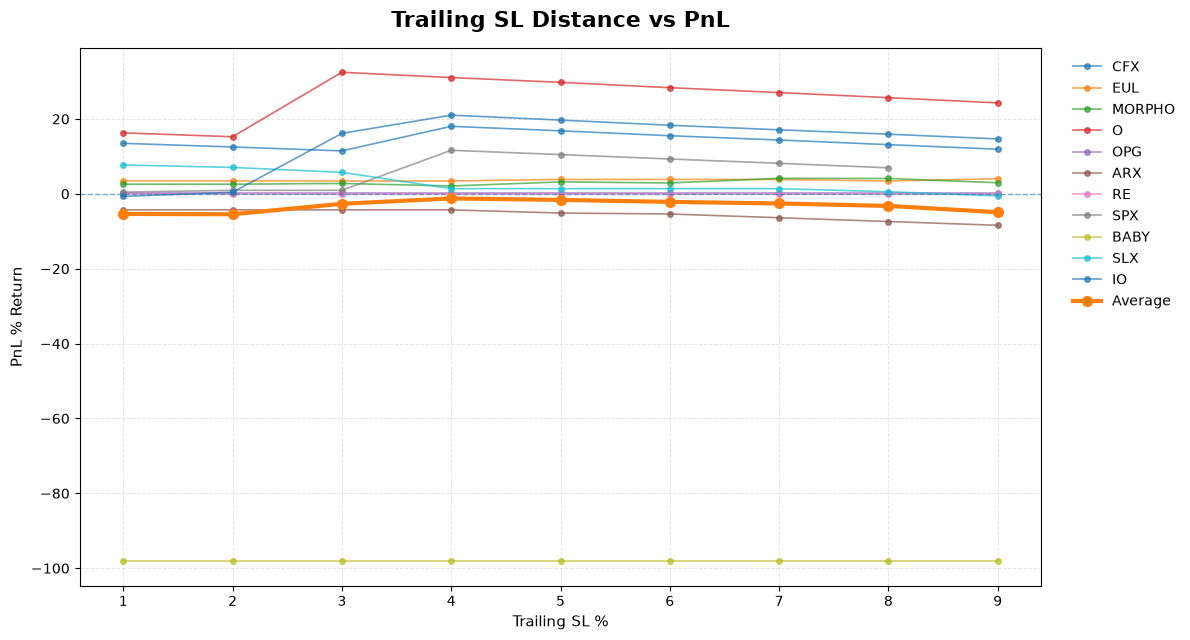

In [4]:
fig, ax, plot_data = plot_lines_with_average(
    data = results,
    title = "Trailing SL Distance vs PnL",
    xlabel = "Trailing SL %",
    ylabel = "PnL % Return",
)

## Testing Volume Based Exit

In [11]:
TIME_INTERVAL_MS = 15000

results = {}
for index, row in notifications.iterrows():
    distance_list = []
    pnl_list = []
    try: 
        for i in range(95, 60, -5):
            pnl_percent = simulate_volume_exit(
                asset_name=row["asset"],
                entry_time=row["notification_time"],
                time_interval_ms=TIME_INTERVAL_MS,
                volume_drop_percent=i
            )
            distance_list.append(i)
            pnl_list.append(pnl_percent)

        results[row["asset"]] = (distance_list, pnl_list)

    except ValueError: 
        print(f"Skipping {row["asset"]}, no prices found")
    except RuntimeError: 
        print(f"Stopping {row["asset"]} early: trailing stop was not triggered within the replay window")
        results[row["asset"]] = (distance_list, pnl_list)


Skipping USDG, no prices found
Skipping META2, no prices found
Skipping RLUSD, no prices found
Skipping GEOD, no prices found
Skipping DRV, no prices found
Skipping AI, no prices found
Skipping TRAC, no prices found


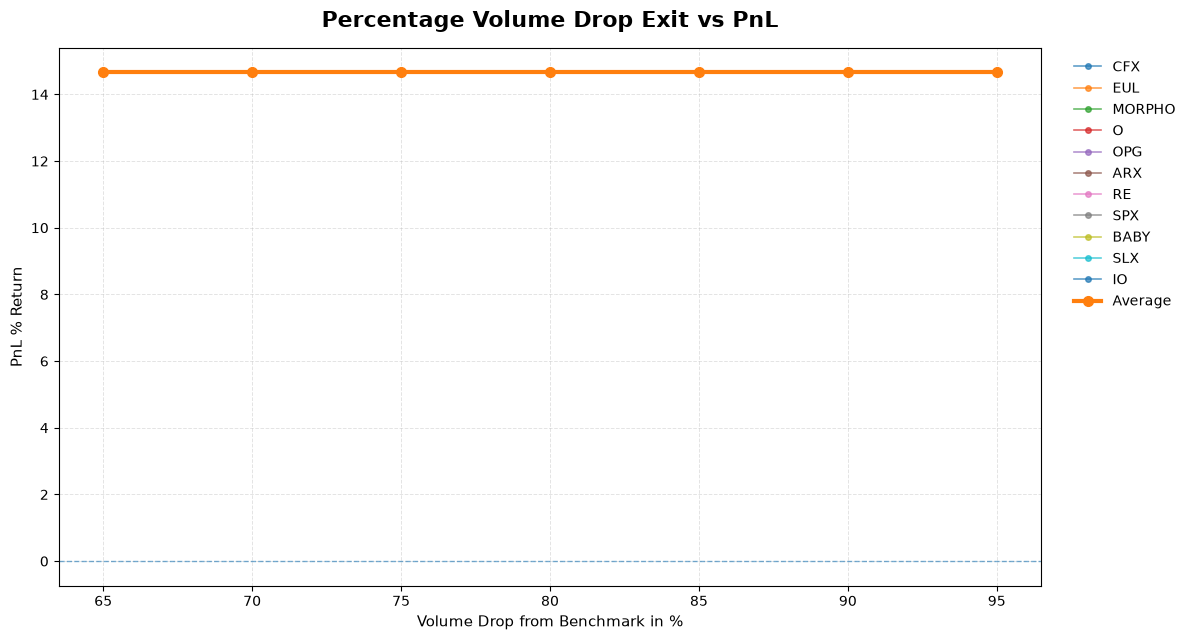

In [6]:
fig, ax, plot_data = plot_lines_with_average(
    data = results,
    title = "Percentage Volume Drop Exit vs PnL",
    xlabel = "Volume Drop from Benchmark in %",
    ylabel = "PnL % Return",
)